# **FundusGuard AI**

**XAI**

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


**Load the Model Architecture**

In [3]:
model = models.resnet50(pretrained=False)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block of layer4 (same as our training)
for param in model.layer4[-1].parameters():
    param.requires_grad = True

# Custom classifier
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.7),
    nn.Linear(256, 2)
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


**Load the Model Weight File**

In [4]:
# Load weights
model.load_state_dict(torch.load("gla_p1_75.pth", map_location=device))

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**Load a Image for Testing**

In [7]:
img_path = "normal.jpg"

image = Image.open(img_path).convert("RGB")
image = transform(image)
image = image.unsqueeze(0).to(device)

In [8]:
import torch.nn.functional as F

with torch.no_grad():
    outputs = model(image)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

classes = ['glaucoma', 'normal']

print("Prediction:", classes[predicted.item()])
print("Confidence:", confidence.item())

Prediction: normal
Confidence: 0.9882461428642273


In [ ]:
img_path = "glaucoma.jpg"

image = Image.open(img_path).convert("RGB")
image = transform(image)
image = image.unsqueeze(0).to(device)

In [ ]:
import torch.nn.functional as F

with torch.no_grad():
    outputs = model(image)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

classes = ['glaucoma', 'normal']

print("Prediction:", classes[predicted.item()])
print("Confidence:", confidence.item())

Prediction: normal glaucoma
Confidence: 0.5285664796829224


In [9]:
import torch.nn.functional as F

img_path = "glaucoma.jpg"
# img_path = "normal.jpg"

image = Image.open(img_path).convert("RGB")
image = transform(image)
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(image)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)
    pred = (probs[:, 1] > 0.7).long()

classes = ['glaucoma', 'normal']

print("Prediction:", classes[pred.item()])
print("Confidence:", confidence.item())

Prediction: glaucoma
Confidence: 0.5285664796829224


**XAI**

In [12]:
!pip install grad-cam
!pip install torch torchvision torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 49.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=41bc2c0fa615635a72d07a99863a96718459561631c6eefa3d8c335ab0c922ef
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [14]:
import cv2
import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [15]:
target_layers = [model.layer4[-1]]

In [16]:
def predict_image(img_path):
    image = Image.open(img_path).convert("RGB")
    image = transform(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)
        pred = (probs[:, 1] > 0.7).long()

    classes = ['glaucoma', 'normal']

    print("Prediction:", classes[pred.item()])
    print("Confidence:", confidence.item())

In [17]:
img_path = "glaucoma.jpg"
predict_image(img_path)


Prediction: glaucoma
Confidence: 0.5285664796829224


In [18]:
# For model
image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

# For visualization (no normalization)
rgb_img = np.array(image.resize((224, 224))) / 255.0

In [19]:
cam = GradCAM(model=model, target_layers=target_layers)

# target class (use your predicted class)
targets = [ClassifierOutputTarget(pred.item())]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

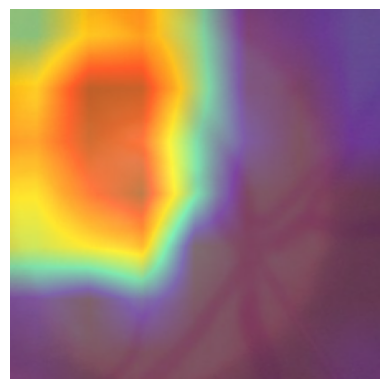

In [20]:
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

import matplotlib.pyplot as plt

plt.imshow(visualization)
plt.axis('off')